# Wine Price Prediction with CatBoost

## 基本情報

- 主題: CatBoost 
- 作成者: 荒田禎之
- 位置づけ: CatBoost を用いた予測モデルの構築
- 使用データ: Wine Review
- 分析課題: Wine Reviews データを使い、数値・カテゴリ変数から $\log(\mathrm{price})$ を CatBoost で予測
- 到達目標: 
  - 実際のデータを用いて、CatBoost モデルを構築する
  - カテゴリ変数が多い・重要である場合に、CatBoost が有効であることを理解する
  - 細かい tuning が不要で、強いベースラインになることを理解する

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

Wine Reviews データを使い、数値・カテゴリ変数から $\log(\mathrm{price})$ を CatBoost で予測する。CatBoost はカテゴリ変数を直接扱えるため、One-hot encoding は行わない。

最初にCatBoostを実行環境へインストールし、ファイル操作、データ処理、可視化、モデル作成、データ分割、評価に必要なライブラリを読み込む。`CatBoostRegressor` はカテゴリ変数を文字列のまま扱える勾配ブースティング回帰モデルである。最後にグラフの表示テーマを指定する。


In [2]:
# CatBoost が未インストールの場合のみ、次の行のコメントを外して実行してください。
!pip install catboost

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


## 1. データの読み込みと重複除外

CSV読み込み後、`title` と `description` の組が同じ行を重複レビューとして除外する。読み込み元、削除件数、処理後のデータサイズを表示し、分析対象を確認する。


In [3]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

df = pd.read_csv(csv_path)

# 同じ商品名・レビュー本文を持つ重複レビューを除外
rows_before = len(df)
df = df.drop_duplicates(subset=["title", "description"]).copy()
duplicates_removed = rows_before - len(df)

print(f"Loaded: {csv_path.resolve()}")
print(f"Removed duplicated reviews: {duplicates_removed:,}")
print(f"Shape after deduplication: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

Loaded: /content/data/winemag-data-130k-v2.csv
Removed duplicated reviews: 9,983
Shape after deduplication: 119,988 rows x 14 columns


## 2. 説明変数と目的変数の作成

<!-- カテゴリ列の欠損は専用カテゴリ `__MISSING__` に置き換えます。数値列の欠損は CatBoost が直接処理できます。 -->

評価点 `points` を数値特徴量、国、銘柄名、産地、品種、ワイナリーをカテゴリ特徴量として指定する。価格が欠損または非正の行を除外し、カテゴリ列の欠損を `__MISSING__` という明示的なカテゴリに変換する。説明変数を `X`、価格の自然対数を目的変数 `y` とし、対象行数、特徴量の例、目的変数の分布を表示する。


In [4]:
numeric_features = ["points"]
categorical_features = [
    "country",
    "designation",
    "province",
    "region_1",
    "region_2",
    "variety",
    "winery",
]
feature_columns = numeric_features + categorical_features

model_data = df.loc[
    df["price"].notna() & (df["price"] > 0),
    feature_columns + ["price"],
].copy()

for column in categorical_features:
    model_data[column] = model_data[column].fillna("__MISSING__").astype(str)

X = model_data[feature_columns]
y = np.log(model_data["price"])

print(f"Rows used for modeling: {len(model_data):,}")
display(X.head())
display(y.describe().rename("log_price").to_frame())

Rows used for modeling: 111,593


,points,country,designation,province,region_1,region_2,variety,winery
1,87,Portugal,Avidagos,Douro,__MISSING__,__MISSING__,Portuguese Red,Quinta dos Avidagos
2,87,US,__MISSING__,Oregon,Willamette Valley,Willamette Valley,Pinot Gris,Rainstorm
3,87,US,Reserve Late Harvest,Michigan,Lake Michigan Shore,__MISSING__,Riesling,St. Julian
4,87,US,Vintner's Reserve Wild Child Block,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Sweet Cheeks
5,87,Spain,Ars In Vitro,Northern Spain,Navarra,__MISSING__,Tempranillo-Merlot,Tandem


,log_price
count,111593.000000
mean,3.316905
std,0.659363
min,1.386294
25%,2.833213
50%,3.218876
75%,3.737670
max,8.101678


## 3. CatBoost の学習

<!-- テストデータの20%のうち半分を検証データ、残りを最終評価データとして使用します。検証データは early stopping のみに使い、最終指標はテストデータで計算します。 -->

全データを80%の訓練、10%の検証、10%のテストへ固定乱数で分割する。CatBoostは最大2,000 iteration、学習率0.05、木の深さ8、L2正則化5で学習する。検証RMSEが100 iteration改善しなければearly stoppingし、検証性能が最良だった時点のモデルを採用する。`cat_features` に列名を渡すことで、指定列をカテゴリ特徴量としてCatBoost内部で処理する。


In [5]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train):,}, validation: {len(X_valid):,}, test: {len(X_test):,}")

model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=2_000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=42,
    allow_writing_files=False,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100,
    use_best_model=True,
)

print(f"Best iteration: {model.get_best_iteration():,}")

Train: 89,274, validation: 11,159, test: 11,160
0:	learn: 0.6404881	test: 0.6397820	best: 0.6397820 (0)	total: 642ms	remaining: 21m 24s
100:	learn: 0.3564205	test: 0.3388450	best: 0.3388450 (100)	total: 32.1s	remaining: 10m 3s
200:	learn: 0.3440743	test: 0.3269630	best: 0.3269630 (200)	total: 51.5s	remaining: 7m 41s
300:	learn: 0.3363814	test: 0.3206303	best: 0.3206303 (300)	total: 1m 10s	remaining: 6m 40s
400:	learn: 0.3309102	test: 0.3170349	best: 0.3170349 (400)	total: 1m 31s	remaining: 6m 2s
500:	learn: 0.3261614	test: 0.3141411	best: 0.3141411 (500)	total: 1m 49s	remaining: 5m 28s
600:	learn: 0.3229352	test: 0.3124660	best: 0.3124660 (600)	total: 2m 9s	remaining: 5m 1s
700:	learn: 0.3198008	test: 0.3110945	best: 0.3110945 (700)	total: 2m 28s	remaining: 4m 35s
800:	learn: 0.3171783	test: 0.3099463	best: 0.3099463 (800)	total: 2m 47s	remaining: 4m 10s
900:	learn: 0.3148526	test: 0.3089780	best: 0.3089780 (900)	total: 3m 7s	remaining: 3m 49s
1000:	learn: 0.3125917	test: 0.3080817	bes

## 4. テストデータでの評価

モデル選択に使っていないテストデータからlog価格を予測する。RMSEは大きな誤差を強く評価し、MAEは平均的な絶対誤差、$R^2$ はlog価格の分散をモデルがどの程度説明したかを表す。最後に実測値と予測値を指数変換してドル価格へ戻し、価格単位のMAEも計算する。


In [6]:
y_pred = model.predict(X_test)

metrics = pd.Series({
    "RMSE (log price)": mean_squared_error(y_test, y_pred) ** 0.5,
    "MAE (log price)": mean_absolute_error(y_test, y_pred),
    "R2 (log price)": r2_score(y_test, y_pred),
    "MAE (price, USD)": mean_absolute_error(np.exp(y_test), np.exp(y_pred)),
})
display(metrics.to_frame("value"))

,value
RMSE (log price),0.304203
MAE (log price),0.221151
R2 (log price),0.791654
"MAE (price, USD)",9.353404


### 予測値と残差を可視化するコード

左図では実際のlog価格と予測log価格を比較し、点が45度の破線に近いほど正確な予測であることを示す。右図では残差を「実際値 − 予測値」として計算し、その分布を確認する。残差の中心が0からずれていれば系統的な過大・過小予測、裾が長ければ一部の大きな誤差が疑われる。


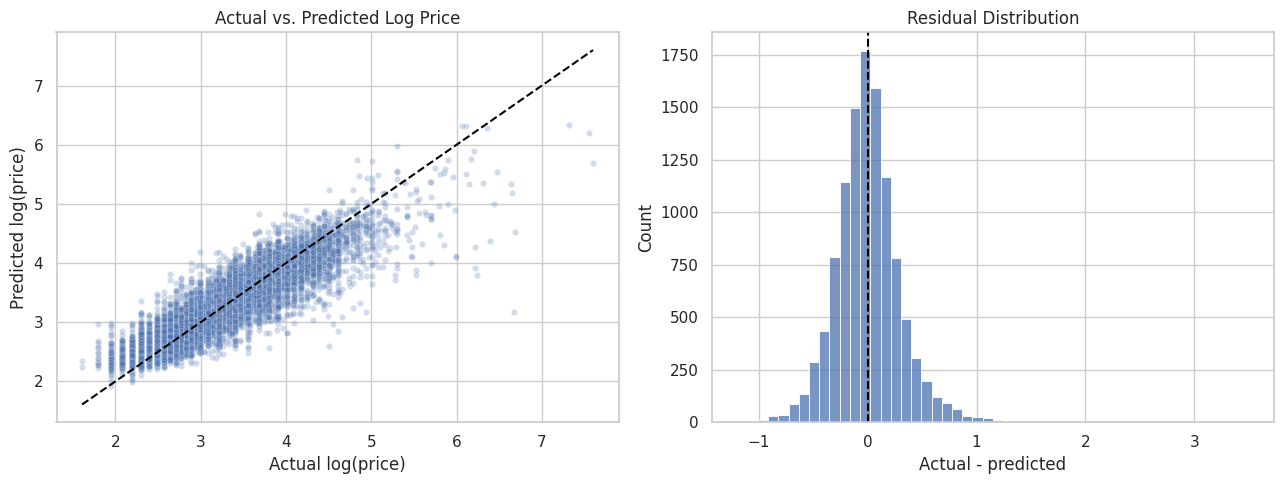

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, s=20, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

residuals = y_test - y_pred
sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()

## 5. 特徴量重要度

学習済みCatBoostから各入力列の特徴量重要度を取得し、高い順に表で表示する。さらに横棒グラフにして、評価点、産地、品種、ワイナリーなどがモデルの分岐へどの程度寄与したかを比較する。

数値変数 `points` だけでなく、`region_1`（産地）や `variety`（ブドウの品種）が有効な説明変数になっていることが分かる。

,importance
points,27.070301
region_1,15.922918
variety,14.187571
winery,13.327942
designation,9.105630
country,8.711985
province,6.042446
region_2,5.631207


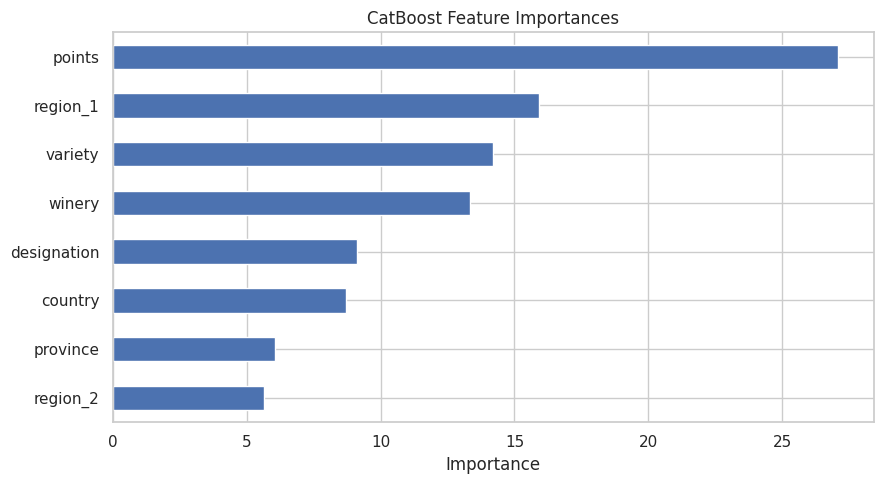

In [8]:
feature_importance = (
    pd.Series(
        model.get_feature_importance(),
        index=feature_columns,
        name="importance",
    )
    .sort_values(ascending=False)
)
display(feature_importance.to_frame())

plt.figure(figsize=(9, 5))
feature_importance.sort_values().plot.barh()
plt.title("CatBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. 予測結果の例

テストデータの先頭10件について、各特徴量、実際のドル価格、予測したドル価格を並べて表示する。log価格を指数変換して元の価格尺度に戻すことで、集約指標だけでは分からない個別予測のずれや、特定の産地・品種で生じる過大・過小予測を目視確認できる。


In [9]:
prediction_examples = X_test.head(10).copy()
prediction_examples["actual_price"] = np.exp(y_test.head(10))
prediction_examples["predicted_price"] = np.exp(model.predict(X_test.head(10)))
display(prediction_examples)

,points,country,designation,province,region_1,region_2,variety,winery,actual_price,predicted_price
54940,93,France,Laplace,Southwest France,Madiran,__MISSING__,Tannat,Château d'Aydie,15.0,39.122471
73486,94,France,Schlossberg Grand Cru,Alsace,Alsace,__MISSING__,Riesling,Jean-Baptiste Adam,54.0,41.526763
15262,93,US,Heritage,California,Livermore Valley,Central Coast,Cabernet Sauvignon,Occasio,60.0,47.392913
119338,87,Spain,Crianza,Northern Spain,Toro,__MISSING__,Tinta de Toro,Cyan,26.0,17.643100
99251,88,France,__MISSING__,Bordeaux,Bordeaux,__MISSING__,Bordeaux-style Red Blend,Château Arnaucosse,10.0,14.563709
16802,89,Germany,Essence,Mosel,__MISSING__,__MISSING__,Riesling,S.A. Prüm,13.0,18.409259
105097,89,Italy,__MISSING__,Veneto,Amarone della Valpolicella,__MISSING__,Red Blend,Tedeschi,65.0,47.443305
37897,85,France,Tradition,Alsace,Alsace,__MISSING__,Pinot Blanc,Kuentz-Bas,17.0,15.579086
5103,86,US,Reserve,Washington,Horse Heaven Hills,Columbia Valley,Cabernet Sauvignon,Canoe Ridge,24.0,24.837763
61801,85,France,Le Temps des Vendanges Sauvignon Blanc-Loin de...,Southwest France,__MISSING__,__MISSING__,White Blend,Georges Vigouroux,9.0,12.236008
